# LOAN DEFAULT PREDICTION USING MACHINE LEARNING

# 1. problem statement

The objective of this project is to build a predictive model that can identify whether a customer is likely to default on a loan. Loan default prediction is a critical problem in the financial industry, as it helps institutions minimize risk and make informed lending decisions.

In this project, we will analyze customer financial and demographic data to understand patterns associated with loan default and build a classification model to predict default outcomes.

# 2. Dataset Description

The dataset contains information about loan applicants and their financial background.

Features include:
- Age: Applicant's age
- Income: Applicant's income
- LoanAmount: Amount of loan taken
- CreditScore: Creditworthiness score
- MonthsEmployed: Employment duration
- NumCreditLines: Number of credit lines
- InterestRate: Loan interest rate
- LoanTerm: Duration of loan
- DTIRatio: Debt-to-Income ratio
- Education: Education level
- EmploymentType: Type of employment
- MaritalStatus: Marital status
- HasMortgage: Whether applicant has mortgage(home loan)
- HasDependents: Dependents status
- LoanPurpose: Purpose of loan
- HasCoSigner: Whether loan has co-signer

Target Variable:
- Default → 1 indicates default, 0 indicates no default

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [3]:
df = pd.read_csv(r"C:\Users\HP\OneDrive\Desktop\Loan_default.csv")  
df.head()


,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [4]:
df.shape
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  object 
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  object 
 11  EmploymentType  255347 non-null  object 
 12  MaritalStatus   255347 non-null  object 
 13  HasMortgage     255347 non-null  object 
 14  HasDependents   255347 non-null  object 
 15  LoanPurpose     255347 non-null  object 
 16  HasCoSigner     255347 non-null  object 
 17  Default   

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default
count,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000
mean,43.498306,82499.304597,127578.865512,574.264346,59.541976,2.501036,13.492773,36.025894,0.500212,0.116128
std,14.990258,38963.013729,70840.706142,158.903867,34.643376,1.117018,6.636443,16.969330,0.230917,0.320379
min,18.000000,15000.000000,5000.000000,300.000000,0.000000,1.000000,2.000000,12.000000,0.100000,0.000000
25%,31.000000,48825.500000,66156.000000,437.000000,30.000000,2.000000,7.770000,24.000000,0.300000,0.000000
50%,43.000000,82466.000000,127556.000000,574.000000,60.000000,2.000000,13.460000,36.000000,0.500000,0.000000
75%,56.000000,116219.000000,188985.000000,712.000000,90.000000,3.000000,19.250000,48.000000,0.700000,0.000000
max,69.000000,149999.000000,249999.000000,849.000000,119.000000,4.000000,25.000000,60.000000,0.900000,1.000000


In [5]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

num_cols, cat_cols

(Index(['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed',
        'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Default'],
       dtype='object'),
 Index(['LoanID', 'Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage',
        'HasDependents', 'LoanPurpose', 'HasCoSigner'],
       dtype='object'))

In [6]:
df.isnull().sum()

LoanID            0
Age               0
Income            0
LoanAmount        0
CreditScore       0
MonthsEmployed    0
NumCreditLines    0
InterestRate      0
LoanTerm          0
DTIRatio          0
Education         0
EmploymentType    0
MaritalStatus     0
HasMortgage       0
HasDependents     0
LoanPurpose       0
HasCoSigner       0
Default           0
dtype: int64

# 1. Default Distribution

<Axes: xlabel='Default', ylabel='count'>

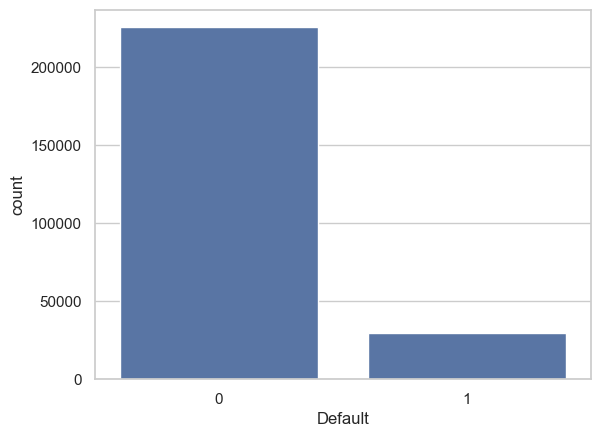

In [7]:
sns.countplot(x='Default', data=df)

### Insights

- Most borrowers in the dataset did not default on their loans, which shows that loan repayment is more common than default.

- Only a small portion of borrowers defaulted, indicating that default cases are relatively rare in this dataset.

- There is a clear imbalance between default and non-default cases, with non-default cases being much higher.

- Because of this imbalance, the model may focus more on predicting non-default cases and may miss some default cases.

- This means we should not rely only on accuracy and should carefully evaluate how well the model identifies default cases.

# 2. Income Distribution

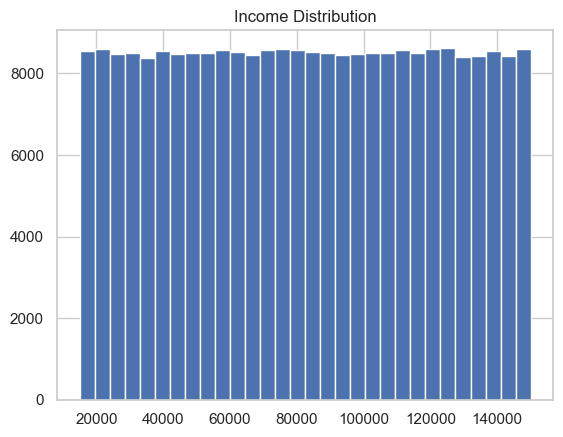

In [8]:
df['Income'].hist(bins=30)
plt.title("Income Distribution")
plt.show()

### Insights

- The income values are spread quite evenly across the range, showing that borrowers belong to different income levels.

- There is no strong concentration in a single income range, which means the dataset includes both low-income and high-income individuals.

- There are no extreme spikes or unusual peaks, indicating that the data is fairly well distributed without heavy skewness.

- Since income is widely distributed, it alone may not fully explain loan default and should be analyzed along with other features like loan amount and DTI ratio.

- A balanced spread of income values is useful for building a more general and unbiased prediction model.

# 3. Loan Amount distribution

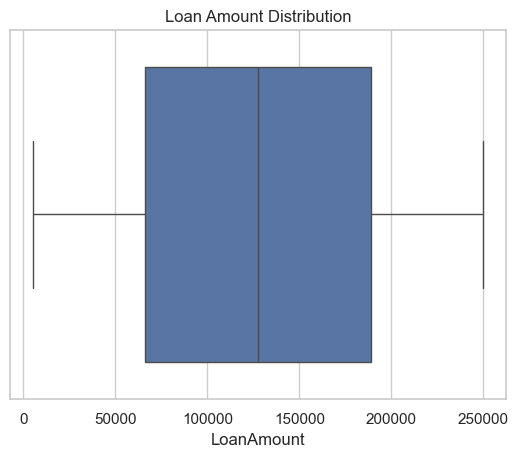

In [9]:
sns.boxplot(x=df['LoanAmount'])
plt.title("Loan Amount Distribution")
plt.show()

### Insights

- The loan amounts are spread across a wide range, showing that borrowers take both small and large loans.

- Most borrowers take loan amounts around the middle range, as indicated by the median.

- Higher loan amounts may increase the risk of default, especially if the borrower’s income is low.

# 4. Credit Score vs Default

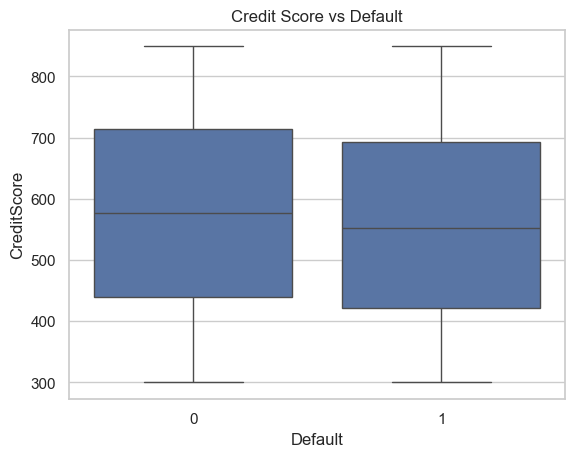

In [10]:
sns.boxplot(x='Default', y='CreditScore', data=df)
plt.title("Credit Score vs Default")
plt.show()

### Insights

- Borrowers who default (1) generally have slightly lower credit scores compared to those who do not default (0).

- Higher credit scores are associated with a lower risk of default, indicating better financial reliability.

- Credit score is an important feature and can strongly help in predicting whether a borrower will default or not.

# 5. Income vs Loan Amount

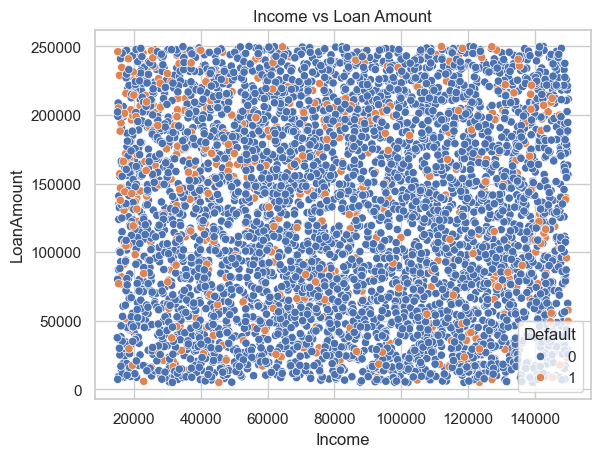

In [11]:
df_sample = df.sample(5000)

sns.scatterplot(x='Income', y='LoanAmount', hue='Default', data=df_sample)
plt.title("Income vs Loan Amount")
plt.show()


### Insights

- There is no strong clear relationship between income and loan amount, as the points are spread widely across the chart.

- Default cases (1) are spread throughout the plot, showing that defaults can happen at both low and high income levels.

- Borrowers with high loan amounts and relatively lower income may have a higher risk of default.

# 6. Correlation Heatmap

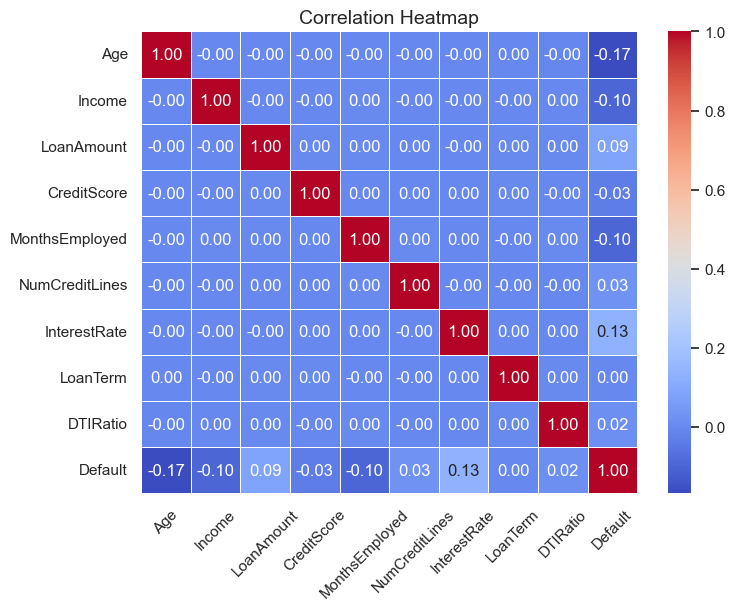

In [12]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap", fontsize=14)
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.show()


### Insights

- Most features have very low correlation with each other, indicating minimal multicollinearity and that the variables are largely independent.

- All features show only weak relationships with **Default**. Among them, **Age (-0.17)** and **InterestRate (0.13)** have relatively higher correlation compared to others, while **Income** and **MonthsEmployed** (around -0.10) and **LoanAmount (0.09)** show smaller effects.

- No feature exhibits a strong correlation with **Default**, suggesting that no single variable is a strong predictor on its own.

- Therefore, combining multiple features through a machine learning model will be necessary to accurately predict loan default.

# Key Observations

- The dataset is imbalanced, as most borrowers did not default while only a small number of borrowers defaulted.

- Income is evenly distributed across a wide range, showing that the dataset includes borrowers from different income levels.

- Loan amounts vary widely, but most borrowers take moderate loan amounts.

- Borrowers with lower credit scores are more likely to default compared to those with higher credit scores.

- There is no clear relationship between income and loan amount, as values are widely spread.

- Default cases are present across different income and loan ranges, indicating that default depends on multiple factors.

- The correlation heatmap shows weak relationships between most variables, meaning no single feature strongly predicts default on its own.

# 4. Data Cleaning & Preprocessing

In this stage, the dataset is cleaned and transformed to make it suitable for modeling.

The following steps are performed:
- Handling missing values
- Removing duplicate records
- Ensuring correct data types
- Encoding categorical variables into numerical format

# Checking Missing Values

In [13]:
df.isnull().sum()

LoanID            0
Age               0
Income            0
LoanAmount        0
CreditScore       0
MonthsEmployed    0
NumCreditLines    0
InterestRate      0
LoanTerm          0
DTIRatio          0
Education         0
EmploymentType    0
MaritalStatus     0
HasMortgage       0
HasDependents     0
LoanPurpose       0
HasCoSigner       0
Default           0
dtype: int64

The dataset is checked for missing values to identify incomplete data entries that may affect model performance.

# Removing Duplicates

In [14]:
df.duplicated().sum()

np.int64(0)

 checked if it has Duplicate records to avoid redundancy and ensure data quality.

# Removing Irrelevant Columns  

In [15]:
df.drop(columns=['LoanID'], inplace=True)

##  Consistency Check

In [16]:
# Check unique values
for col in ['HasMortgage', 'HasDependents', 'HasCoSigner']:
    print(col, df[col].unique())

HasMortgage ['Yes' 'No']
HasDependents ['Yes' 'No']
HasCoSigner ['Yes' 'No']


### Value Consistency Check
Value consistency was checked for boolean features because they are expected to have only specific values like 0 or 1, making it easier to detect inconsistencies.

The dataset was checked for inconsistencies in values such as incorrect labels or mixed formats.

No inconsistencies were found, and the data was already in a consistent format.

#  Data Type Verification

In [17]:
df.dtypes

Age                 int64
Income              int64
LoanAmount          int64
CreditScore         int64
MonthsEmployed      int64
NumCreditLines      int64
InterestRate      float64
LoanTerm            int64
DTIRatio          float64
Education          object
EmploymentType     object
MaritalStatus      object
HasMortgage        object
HasDependents      object
LoanPurpose        object
HasCoSigner        object
Default             int64
dtype: object

All columns are verified to ensure they have appropriate data types for further processing.

# Outlier Detection

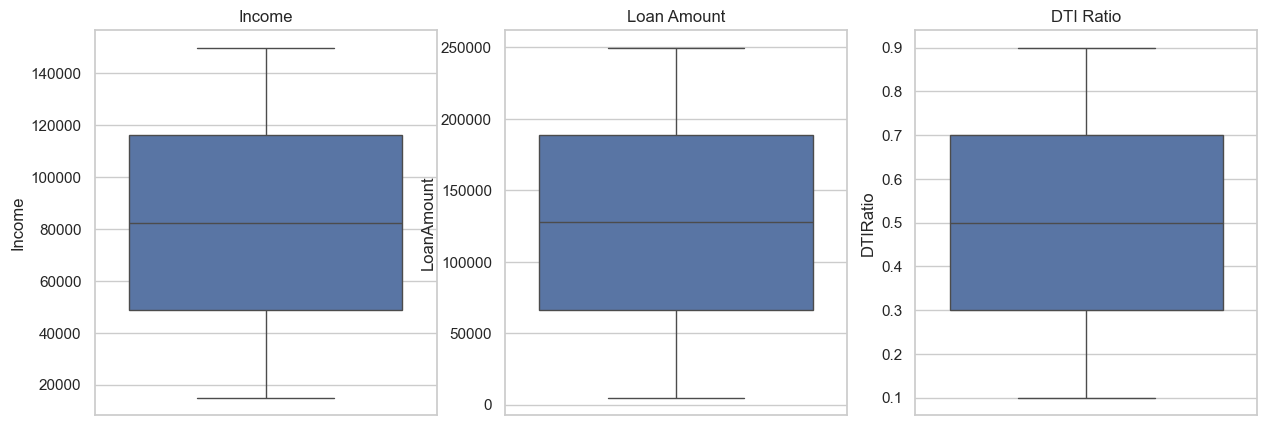

In [18]:
fig, axes = plt.subplots(1,3, figsize=(15,5))

sns.boxplot(y=df['Income'], ax=axes[0])
axes[0].set_title("Income")

sns.boxplot(y=df['LoanAmount'], ax=axes[1])  
axes[1].set_title("Loan Amount")

sns.boxplot(y=df['DTIRatio'], ax=axes[2])
axes[2].set_title("DTI Ratio")

plt.show()

### Outlier Detection insight

Outlier detection was performed on continuous numerical features like income, loan amount, and DTI ratio because they have wide value ranges and can significantly impact model performance, whereas categorical and boolean features do not have outliers.

The boxplots do not show any significant outliers, as most data points lie within the whiskers.

The variations observed are normal and represent real-world financial differences among borrowers.

Therefore, no outlier treatment was required.

# Encoding Categorical Variables

# Binary Encoding

In [19]:
binary_cols = ['HasMortgage', 'HasDependents', 'HasCoSigner']
for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

# One-Hot Encoding

In [20]:
df = pd.get_dummies(df, columns=[
    'Education',
    'EmploymentType',
    'MaritalStatus',
    'LoanPurpose'
], drop_first=True)

Categorical variables are converted into numerical format using encoding techniques. Binary variables are mapped to 0 and 1, while multi-category variables are transformed using one-hot encoding.


In [21]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 25 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Age                           255347 non-null  int64  
 1   Income                        255347 non-null  int64  
 2   LoanAmount                    255347 non-null  int64  
 3   CreditScore                   255347 non-null  int64  
 4   MonthsEmployed                255347 non-null  int64  
 5   NumCreditLines                255347 non-null  int64  
 6   InterestRate                  255347 non-null  float64
 7   LoanTerm                      255347 non-null  int64  
 8   DTIRatio                      255347 non-null  float64
 9   HasMortgage                   255347 non-null  int64  
 10  HasDependents                 255347 non-null  int64  
 11  HasCoSigner                   255347 non-null  int64  
 12  Default                       255347 non-nul

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,HasMortgage,...,Education_PhD,EmploymentType_Part-time,EmploymentType_Self-employed,EmploymentType_Unemployed,MaritalStatus_Married,MaritalStatus_Single,LoanPurpose_Business,LoanPurpose_Education,LoanPurpose_Home,LoanPurpose_Other
0,56,85994,50587,520,80,4,15.23,36,0.44,1,...,False,False,False,False,False,False,False,False,False,True
1,69,50432,124440,458,15,1,4.81,60,0.68,0,...,False,False,False,False,True,False,False,False,False,True
2,46,84208,129188,451,26,3,21.17,24,0.31,1,...,False,False,False,True,False,False,False,False,False,False
3,32,31713,44799,743,0,3,7.07,24,0.23,0,...,False,False,False,False,True,False,True,False,False,False
4,60,20437,9139,633,8,4,6.51,48,0.73,0,...,False,False,False,True,False,False,False,False,False,False


# Issues Found in Dataset

- No missing values were found in the dataset.
- No duplicate records were present.
- The LoanID column was identified as irrelevant for prediction.
- Categorical variables required encoding to be used in machine learning models.
- No significant outliers were observed in key numerical features.

# Cleaning Steps Performed

- Verified that there are no missing values in the dataset.
- Checked and confirmed that no duplicate records exist.
- Removed the LoanID column as it does not contribute to prediction.
- Performed value consistency checks and confirmed data was already consistent.
- Converted categorical variables into numerical format using one-hot encoding.
- Converted boolean columns into integer format for model compatibility.
- Performed outlier detection using boxplots and retained all values as they were valid.

# Assumptions Taken During Preprocessing

- The dataset values are assumed to be accurate and correctly recorded.
- Since no missing values were present, no imputation was required.
- Encoded categorical variables are assumed to correctly represent the original categories.
- All numerical values are assumed to be valid and free from major errors.
- Observed variations in data are considered normal and representative of real-world scenarios.

##  Feature Engineering

New features are created to better capture financial relationships between variables and improve prediction of loan default.

# Income to Loan Ratio

In [22]:
df['Income_Loan_Ratio'] = df['Income'] / df['LoanAmount']

**How it was created:**
Income divided by LoanAmount.

**Why it helps:**
Represents the borrower’s repayment ability.

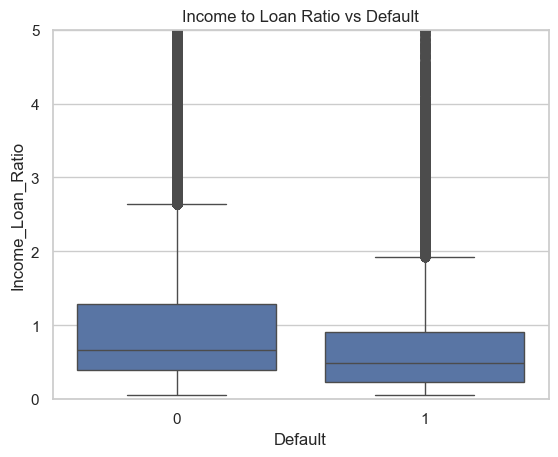

In [23]:
sns.boxplot(x='Default', y='Income_Loan_Ratio', data=df)
plt.ylim(0, 5)  
plt.title("Income to Loan Ratio vs Default")
plt.show()

### Observation

The visualization shows that borrowers with higher income-to-loan ratios are less likely to default.

Borrowers who default tend to have lower ratios, indicating weaker financial capacity.

This confirms that repayment ability plays an important role in predicting loan default.

# EMI

In [24]:
df['EMI'] = df['LoanAmount'] / df['LoanTerm']

**How it was created:**
LoanAmount divided by LoanTerm.

**Why it helps:**
Represents the monthly repayment burden.

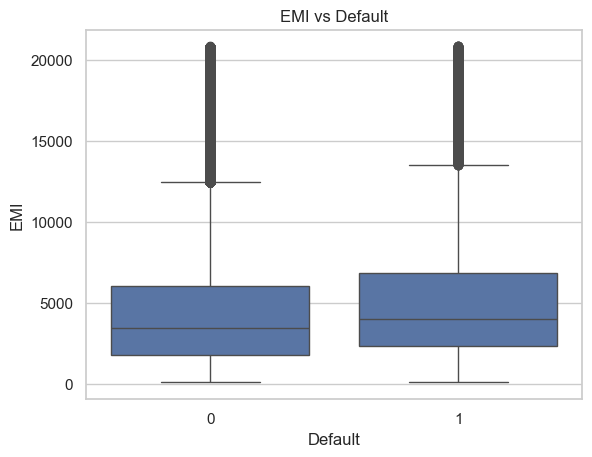

In [25]:
sns.boxplot(x='Default', y='EMI', data=df)
plt.title("EMI vs Default")
plt.show()

 Higher EMI values are associated with higher default risk due to increased financial burden.


# Credit Score to Loan Ratio

In [26]:
df['Credit_Loan_Ratio'] = df['CreditScore'] / df['LoanAmount']

**How it was created:**
CreditScore divided by LoanAmount.

**Why it helps:**
Combines creditworthiness with loan size.

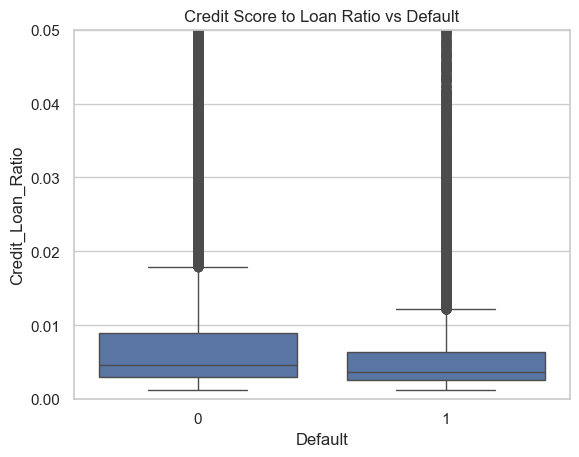

In [27]:
sns.boxplot(x='Default', y='Credit_Loan_Ratio', data=df)
plt.ylim(0, 0.05)
plt.title("Credit Score to Loan Ratio vs Default")
plt.show()

Lower credit-to-loan ratio is linked with higher default probability.

The engineered features provided better insights into borrower financial behavior and showed clear relationships with loan default.

# 6. Modeling

In this stage, a machine learning model is built to predict whether a borrower will default on a loan.

Since the target variable (Default) is binary (0 or 1), this is a classification problem.

Logistic Regression is used as the primary model.

In [28]:
X = df.drop(columns=['Default'])
y = df['Default']

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

The dataset is split into training and testing sets to evaluate model performance on unseen data.

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [31]:
# MODEL EVALUATION

In [32]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))

Accuracy: 0.6805169375367143
Precision: 0.22051089406461308
Recall: 0.6964406779661017


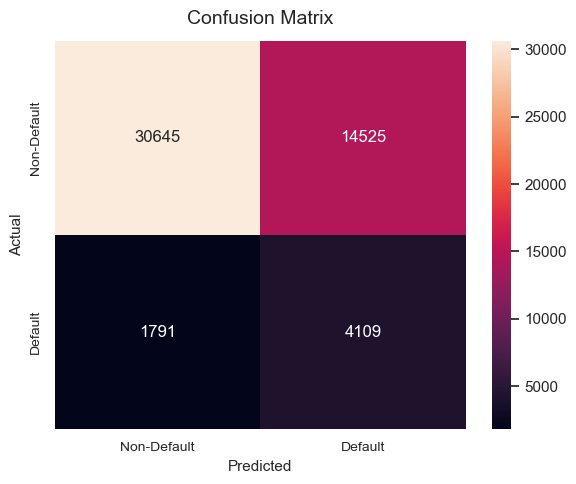

In [33]:

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

labels = ['Non-Default', 'Default']

plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=labels, yticklabels=labels)

plt.title('Confusion Matrix', fontsize=14, pad=12)
plt.xlabel('Predicted', fontsize=11)
plt.ylabel('Actual', fontsize=11)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()

# Save clean image
plt.savefig('confusion_matrix_clean.png', dpi=300, bbox_inches='tight')

plt.show()

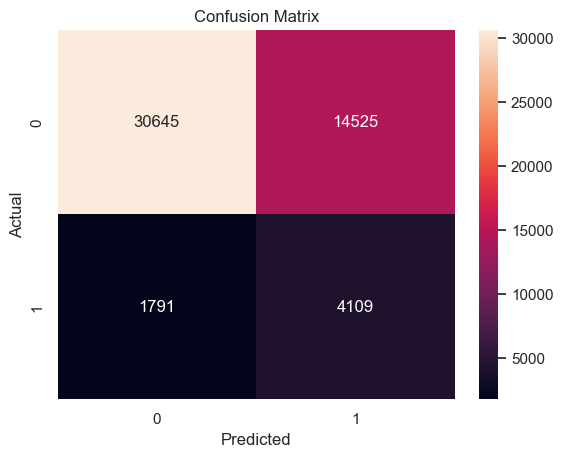

In [34]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

### Confusion Matrix Interpretation

The model shows improved performance in identifying defaulters.

- True Negatives (30645): Correctly identified non-defaulters
- True Positives (4109): Correctly identified defaulters
- False Positives (14525): Non-defaulters incorrectly predicted as defaulters
- False Negatives (1791): Defaulters missed by the model

The model has significantly reduced false negatives, which is important in loan risk prediction. Although false positives are higher, this is acceptable in financial applications where identifying risky customers is more critical.

Overall, the model prioritizes recall, making it effective for detecting potential defaulters.

In [35]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, recall_score

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Decision Tree Recall:", recall_score(y_test, y_pred_dt))

Decision Tree Accuracy: 0.8049344037595457
Decision Tree Recall: 0.2276271186440678


## Decision Tree Model Evaluation

The Decision Tree model achieved an accuracy of around 80%, indicating reasonable overall performance.

However, the recall score is low (~0.23), meaning the model fails to identify a large number of actual defaulters.

This makes the model less suitable for loan default prediction, where detecting defaulters is more critical.

In comparison, Logistic Regression performed better in terms of recall after handling class imbalance, making it a more appropriate choice for this problem.

This highlights that higher accuracy does not always mean a better model, especially in imbalanced classification problems.

# Model Evaluation and Interpretation

## Model Choice

Logistic Regression was selected as the primary model for this problem since the target variable (Default) is binary (0 or 1).

This model is suitable for classification tasks and provides interpretable results, making it easier to understand the relationship between features and the probability of default.

A Decision Tree model was also implemented for comparison, as it can capture non-linear relationships between features.

However, Logistic Regression was chosen as the final model because it performed better in terms of recall after handling class imbalance, making it more effective for detecting defaulters.

---

## Evaluation Metrics

The model performance was evaluated using the following metrics:

- **Accuracy**: Measures the overall correctness of the model.
- **Precision**: Indicates how many predicted defaulters are actually defaulters.
- **Recall**: Measures how well the model identifies actual defaulters.
- **Confusion Matrix**: Provides a detailed breakdown of correct and incorrect predictions.

Since the dataset is imbalanced, recall is considered more important than accuracy.

---

### Interpretation of Results

The confusion matrix shows that the model performs well in predicting non-defaulters, as indicated by a high number of true negatives.

The model has significantly improved in identifying actual defaulters, as seen from the increase in true positives and reduction in false negatives.

However, the model produces a higher number of false positives, meaning some non-defaulters are incorrectly classified as defaulters.

This indicates that the model is now more focused on detecting risky borrowers (high recall), even at the cost of misclassifying some safe customers. This trade-off is acceptable in financial applications where missing a defaulter is more critical than incorrectly flagging a safe borrower.

---
### Key Insights

The model performs well in predicting non-defaulters, with a high number of correct classifications.

The model has improved in identifying defaulters, as the number of missed defaulters (false negatives) has reduced significantly.

There is an increase in false positives, meaning some safe customers are incorrectly classified as defaulters, which is an acceptable trade-off in risk-sensitive applications.

Financial features such as income-to-loan ratio, EMI, and credit-to-loan ratio play an important role in predicting default.

The dataset imbalance affects model performance, but using techniques like class weighting helps improve detection of defaulters.

Improving recall is crucial in this problem, as identifying risky borrowers is more important than avoiding false alarms.


# Insights

- Most borrowers do not default, indicating that the dataset is imbalanced with a higher proportion of non-defaulters.

- Borrowers with higher income relative to loan amount (Income_Loan_Ratio) are less likely to default, showing the importance of repayment capacity.

- Higher EMI values are associated with increased default risk, as larger monthly payments create financial burden.

- Borrowers with lower credit score relative to loan amount are more likely to default, indicating weaker credit strength.

- The model performs well in predicting non-defaulters, with a high number of correct classifications.

- The model has improved in identifying defaulters by reducing false negatives, making it more effective for risk detection.

- There is an increase in false positives, meaning some safe borrowers are incorrectly flagged as defaulters, which is an acceptable trade-off in financial applications.

- Feature engineering helped reveal important financial relationships that were not directly visible in the original dataset and improved model performance.

# Conclusion

The objective of this project was to build a predictive model to identify loan defaulters based on borrower data.

Exploratory Data Analysis helped in understanding the distribution and patterns in the dataset. Data cleaning ensured that the dataset was consistent and ready for modeling. Feature engineering played a key role in creating meaningful financial indicators such as income-to-loan ratio, EMI, and credit-to-loan ratio.

A Logistic Regression model was built to classify borrowers as defaulters or non-defaulters. After addressing class imbalance, the model improved its ability to identify defaulters by reducing false negatives and increasing true positives. Although this led to an increase in false positives, the trade-off is acceptable in financial applications where detecting risky borrowers is more critical.

Overall, the project demonstrates how data preprocessing, feature engineering, and modeling can be used together to analyze borrower behavior and predict loan default. The results highlight the importance of balancing model performance metrics and understanding trade-offs in real-world prediction problems.

---

# Limitations

- The dataset is imbalanced, which affects model performance and leads to a trade-off between recall and precision.

- Although the model improved in detecting defaulters, it produces a higher number of false positives, misclassifying some non-defaulters.

- Logistic Regression is a simple model and may not capture complex relationships between features.

- Some important real-world factors influencing loan default, such as behavioral or external economic conditions, may not be included in the dataset.

---

# Future Improvements

- Apply advanced models such as Random Forest or XGBoost to capture more complex patterns.

- Use techniques like SMOTE, oversampling, or undersampling to better handle class imbalance.

- Perform hyperparameter tuning to optimize model performance.

- Adjust classification threshold to balance precision and recall more effectively.

- Include additional relevant features to improve prediction accuracy.